<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/TradingStrategies/TradingStrategies/Stop_Loss_Logic_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

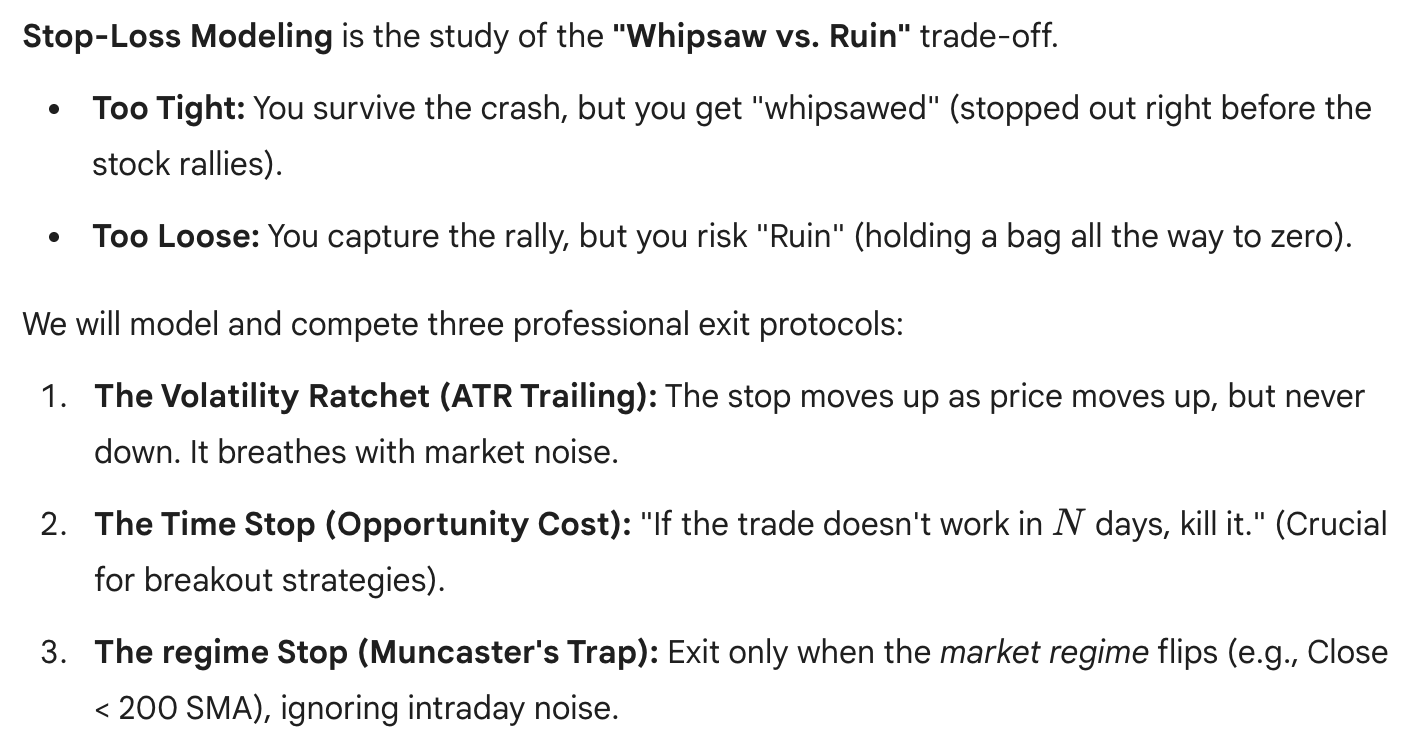

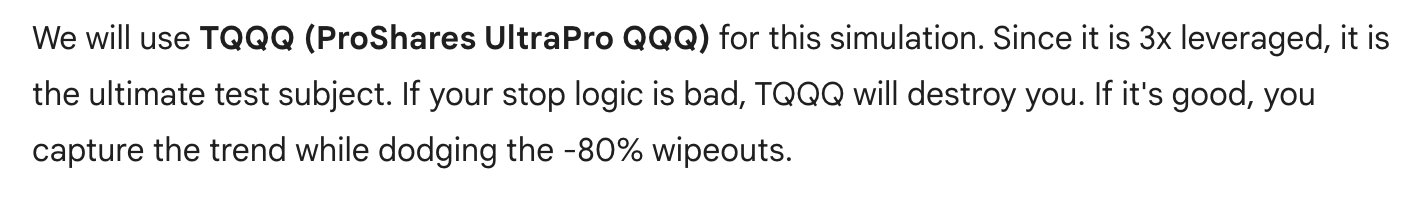

In [11]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [12]:
# --- CONFIGURATION ---
ticker = 'TQQQ'  # 3x Leveraged Nasdaq (High Volatility)
start_date = '2015-01-01'
end_date = '2024-01-01'

In [13]:
print(f"📥 Downloading Data for {ticker}...")
df = yf.download(ticker, start=start_date, end=end_date, progress=False)

# Cleaning
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df[['Open', 'High', 'Low', 'Close']].dropna()

df.head()

📥 Downloading Data for TQQQ...


/tmp/ipython-input-3436603125.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


Price,Open,High,Low,Close
Date,,,,
2015-01-02,1.965958,1.991415,1.892570,1.922204
2015-01-05,1.894360,1.901321,1.819779,1.835690
2015-01-06,1.842253,1.852993,1.737640,1.762899
2015-01-07,1.796510,1.842452,1.784378,1.830717
2015-01-08,1.877852,1.946070,1.871488,1.935130


In [14]:
# --- 1. INDICATORS FOR STOPS ---

# A. ATR (Average True Range) for Volatility Stops
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift())
low_close = np.abs(df['Low'] - df['Close'].shift())
true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df['ATR'] = true_range.rolling(14).mean()

# B. Regime Filter (Simple Moving Average)
df['SMA_200'] = df['Close'].rolling(200).mean()

df.tail()

Price,Open,High,Low,Close,ATR,SMA_200
Date,,,,,,
2023-12-22,24.744208,24.910473,24.274753,24.621954,0.803546,17.827839
2023-12-26,24.763767,25.189211,24.753987,25.071848,0.793985,17.902999
2023-12-27,25.110968,25.262564,24.949594,25.203882,0.749916,17.977737
2023-12-28,25.389710,25.433721,25.071850,25.140312,0.705514,18.048671
2023-12-29,25.125643,25.194105,24.450800,24.793112,0.709572,18.117076


In [15]:
# Entry Signal: Simple "Golden Cross" proxy for testing exits
# We enter when Price > SMA_50 (Trend is up)
df['SMA_50'] = df['Close'].rolling(50).mean()
df['Signal'] = (df['Close'] > df['SMA_50']).astype(int)

# Remove NaN
df.dropna(inplace=True)

print("✅ Indicators Ready. Starting Simulation...")
df.tail()

✅ Indicators Ready. Starting Simulation...


Price,Open,High,Low,Close,ATR,SMA_200,SMA_50,Signal
Date,,,,,,,,
2023-12-22,24.744208,24.910473,24.274753,24.621954,0.803546,17.827839,20.190408,1
2023-12-26,24.763767,25.189211,24.753987,25.071848,0.793985,17.902999,20.327563,1
2023-12-27,25.110968,25.262564,24.949594,25.203882,0.749916,17.977737,20.455089,1
2023-12-28,25.389710,25.433721,25.071850,25.140312,0.705514,18.048671,20.584946,1
2023-12-29,25.125643,25.194105,24.450800,24.793112,0.709572,18.117076,20.723634,1


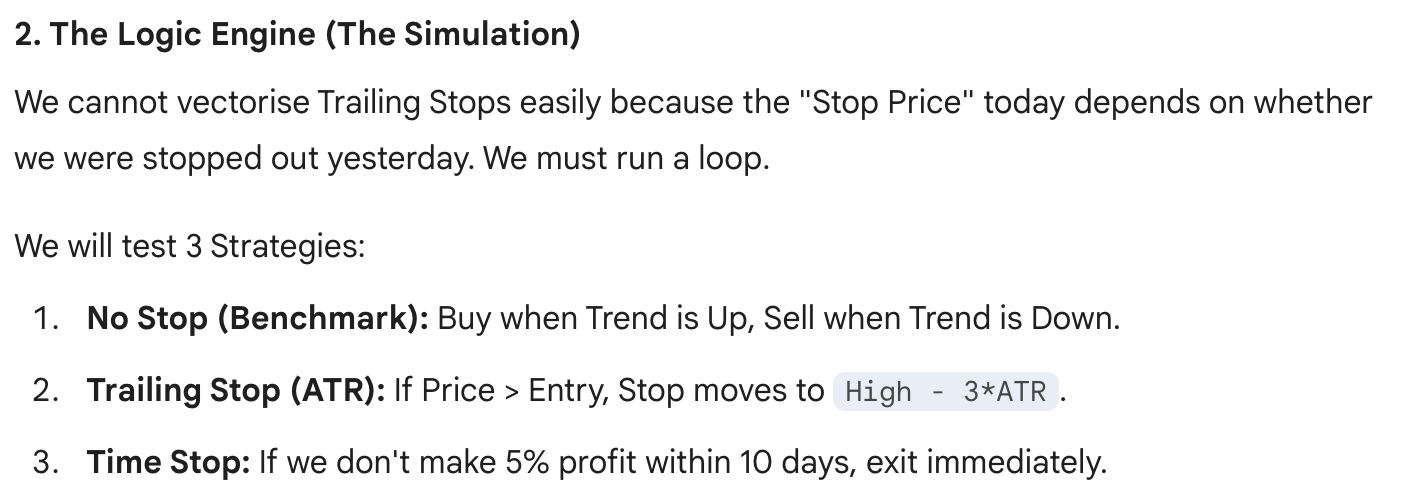

In [16]:
def run_backtest(df, stop_type='None', atr_mult=3.0, time_limit=10):
    capital = 10000
    position = 0
    entry_price = 0
    entry_date_idx = 0
    stop_price = 0
    equity_curve = []

    dates = df.index
    closes = df['Close'].values
    highs = df['High'].values
    lows = df['Low'].values
    atrs = df['ATR'].values
    signals = df['Signal'].values # 1 = Trend Up, 0 = Trend Down

    for i in range(len(df)):

        # --- 1. CHECK EXIT CONDITIONS (If we have a position) ---
        if position > 0:
            sold = False

            # A. HARD STOP / TRAILING STOP CHECK
            if stop_type == 'Trailing_ATR':
                # Update Trailing Stop: Ratchet UP only
                # Logic: Stop is Highest High since entry minus ATR multiple
                # Ideally we track the "Highest High while in trade".
                # For simplicity here: dynamic calculation based on current Low

                # Check if Low hit the stop
                if lows[i] < stop_price:
                    # STOPPED OUT
                    pct_loss = (stop_price - entry_price) / entry_price
                    # Slippage simulation: we execute AT the stop price (optimistic)
                    # or at Open if gap down (more realistic). Let's use Stop Price for logic check.
                    # Reality check: Use min(Open, Stop) to capture gaps.
                    exec_price = min(df['Open'].values[i], stop_price)

                    capital = capital * (exec_price / entry_price)
                    position = 0
                    sold = True

                # If not sold, TRAIL the stop up
                else:
                    # Chandelier Logic: New Stop = Current Close - ATR (if higher than old stop)
                    # A true Chandelier uses Highest High. Let's use Close for stability.
                    new_stop_level = closes[i] - (atr_mult * atrs[i])
                    if new_stop_level > stop_price:
                        stop_price = new_stop_level

            # B. TIME STOP CHECK
            elif stop_type == 'Time_Based':
                days_in_trade = i - entry_date_idx
                current_pnl = (closes[i] / entry_price) - 1

                # Rule: If > 10 days and Profit < 2%, Kill it (Dead money)
                if days_in_trade >= time_limit and current_pnl < 0.02:
                     capital = capital * (closes[i] / entry_price)
                     position = 0
                     sold = True

            # C. SIGNAL EXIT (Trend Reversal) - Applies to ALL strategies as a baseline
            # If Trend goes down (Signal 0), we exit regardless of Stop logic
            if not sold and signals[i] == 0:
                capital = capital * (closes[i] / entry_price)
                position = 0
                sold = True

        # --- 2. CHECK ENTRY CONDITIONS ---
        if position == 0 and signals[i] == 1:
            position = 1
            entry_price = closes[i]
            entry_date_idx = i

            # Set Initial Stop
            if stop_type == 'Trailing_ATR':
                stop_price = closes[i] - (atr_mult * atrs[i])
            elif stop_type == 'Time_Based':
                stop_price = 0 # Not used

        # --- 3. RECORD EQUITY ---
        if position > 0:
            current_val = capital * (closes[i] / entry_price)
        else:
            current_val = capital
        equity_curve.append(current_val)

    return equity_curve

In [17]:
# Run Simulations
print("🏃 Running Backtests...")
eq_no_stop = run_backtest(df, stop_type='None')
eq_atr_stop = run_backtest(df, stop_type='Trailing_ATR', atr_mult=3.0)
eq_time_stop = run_backtest(df, stop_type='Time_Based', time_limit=15)

# Add to DF for plotting
df['Eq_None'] = eq_no_stop
df['Eq_ATR'] = eq_atr_stop
df['Eq_Time'] = eq_time_stop
df.head()

🏃 Running Backtests...


Price,Open,High,Low,Close,ATR,SMA_200,SMA_50,Signal,Eq_None,Eq_ATR,Eq_Time
Date,,,,,,,,,,,
2015-10-16,2.062821,2.078534,2.032787,2.074755,0.088498,2.105701,1.958611,1,10000.000000,10000.000000,10000.000000
2015-10-19,2.065208,2.115331,2.053671,2.111949,0.084051,2.106650,1.955031,1,10179.272897,10179.272897,10179.272897
2015-10-20,2.099220,2.113342,2.057052,2.076943,0.079803,2.107856,1.949203,1,10010.547966,10010.547966,10010.547966
2015-10-21,2.109562,2.115529,2.037560,2.043527,0.079419,2.109259,1.944513,1,9849.488954,9849.488954,9849.488954
2015-10-22,2.094645,2.169830,2.077142,2.164659,0.075498,2.110929,1.941844,1,10433.326147,10433.326147,10433.326147


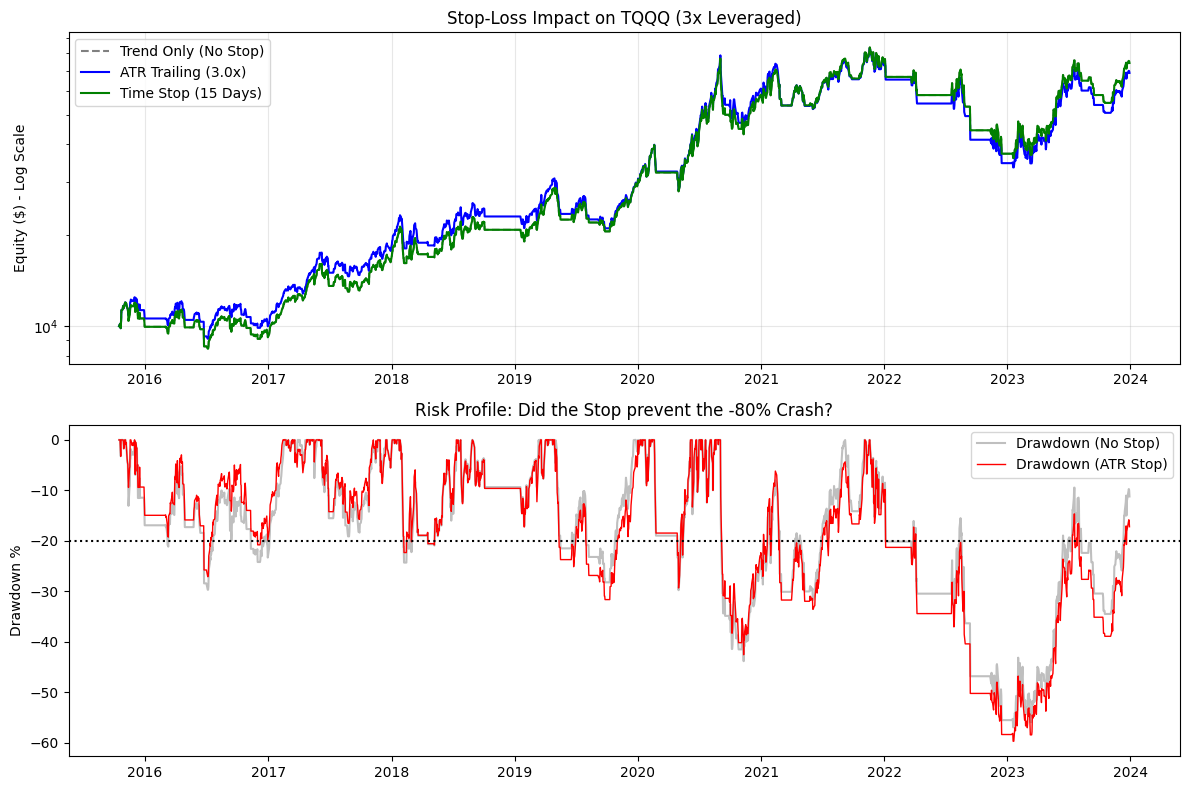

       Strategy Return  Max DD
0       No Stop   642%  -56.9%
1  ATR Trailing   588%  -59.7%
2     Time Stop   642%  -56.9%


In [18]:
# --- PLOTTING ---
plt.figure(figsize=(12, 8))

# Panel 1: Equity Curves
plt.subplot(2, 1, 1)
plt.semilogy(df.index, df['Eq_None'], label='Trend Only (No Stop)', color='gray', linestyle='--')
plt.semilogy(df.index, df['Eq_ATR'], label='ATR Trailing (3.0x)', color='blue')
plt.semilogy(df.index, df['Eq_Time'], label='Time Stop (15 Days)', color='green')
plt.title(f"Stop-Loss Impact on {ticker} (3x Leveraged)")
plt.ylabel("Equity ($) - Log Scale")
plt.legend()
plt.grid(True, alpha=0.3)

# Panel 2: Drawdowns
# Calculate Drawdowns
def get_dd(series):
    return (series / series.cummax() - 1) * 100

dd_none = get_dd(df['Eq_None'])
dd_atr = get_dd(df['Eq_ATR'])

plt.subplot(2, 1, 2)
plt.plot(df.index, dd_none, color='gray', alpha=0.5, label='Drawdown (No Stop)')
plt.plot(df.index, dd_atr, color='red', linewidth=1, label='Drawdown (ATR Stop)')
plt.title("Risk Profile: Did the Stop prevent the -80% Crash?")
plt.ylabel("Drawdown %")
plt.axhline(-20, color='black', linestyle=':')
plt.legend()

plt.tight_layout()
plt.show()

# --- METRICS ---
def quick_stats(name, series):
    total_ret = (series.iloc[-1] / 10000) - 1
    max_dd = get_dd(series).min()
    return {'Strategy': name, 'Return': f"{total_ret*100:.0f}%", 'Max DD': f"{max_dd:.1f}%"}

results = [
    quick_stats('No Stop', df['Eq_None']),
    quick_stats('ATR Trailing', df['Eq_ATR']),
    quick_stats('Time Stop', df['Eq_Time'])
]
print(pd.DataFrame(results))

⚙️ Optimizing 40 combinations...


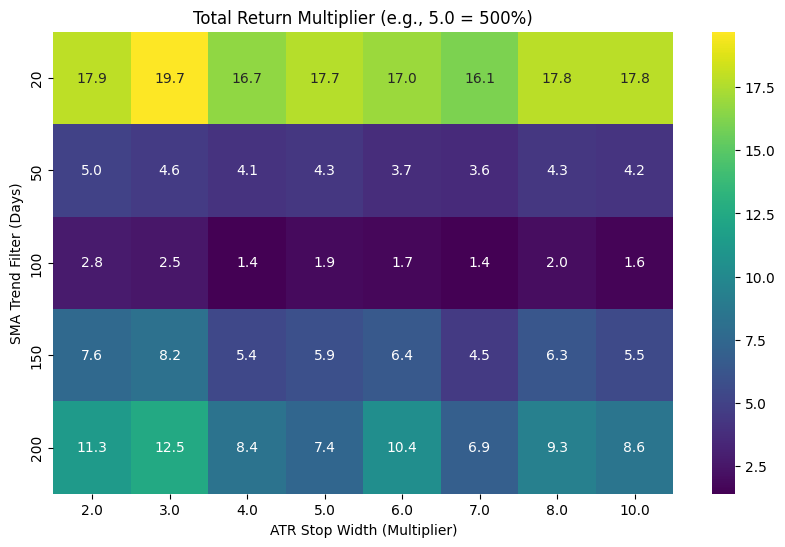

In [19]:
import seaborn as sns

# --- GRID SEARCH ENGINE ---
def run_simulation(df, sma_period, atr_mult):
    # 1. Recalculate Signal based on new SMA
    # Use .copy() to avoid SettingWithCopy warnings
    temp_df = df.copy()
    temp_df['SMA'] = temp_df['Close'].rolling(sma_period).mean()
    temp_df['Signal'] = (temp_df['Close'] > temp_df['SMA']).astype(int)
    temp_df.dropna(inplace=True)

    # 2. Run Backtest Logic (Simplified for Speed)
    capital = 10000
    position = 0
    stop_price = 0
    entry_price = 0  # Initialize entry_price

    closes = temp_df['Close'].values
    lows = temp_df['Low'].values
    atrs = temp_df['ATR'].values
    signals = temp_df['Signal'].values

    for i in range(len(temp_df)):
        # Exit Check
        if position > 0:
            # Check Stop
            if lows[i] < stop_price:
                # Stopped Out
                capital = capital * (stop_price / entry_price) # Optimistic exec
                position = 0

            # Check Signal Reversal (Trend Change)
            elif signals[i] == 0:
                capital = capital * (closes[i] / entry_price)
                position = 0

            # Trailing Logic (Ratchet)
            else:
                new_stop = closes[i] - (atr_mult * atrs[i])
                if new_stop > stop_price:
                    stop_price = new_stop

        # Entry Check
        if position == 0 and signals[i] == 1:
            position = 1
            entry_price = closes[i]
            # Initial Stop
            stop_price = closes[i] - (atr_mult * atrs[i])

    return capital

# --- DEFINING THE GRID ---
sma_params = [20, 50, 100, 150, 200]  # Trend Sensitivity
atr_params = [2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0] # Stop Width

results_matrix = np.zeros((len(sma_params), len(atr_params)))

print(f"⚙️ Optimizing {len(sma_params)*len(atr_params)} combinations...")

for i, sma in enumerate(sma_params):
    for j, atr in enumerate(atr_params):
        final_equity = run_simulation(df, sma, atr)
        # Store Total Return %
        ret_pct = (final_equity / 10000) - 1
        results_matrix[i, j] = ret_pct

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
sns.heatmap(results_matrix, annot=True, fmt=".1f",
            xticklabels=atr_params, yticklabels=sma_params, cmap='viridis')

plt.title("Total Return Multiplier (e.g., 5.0 = 500%)")
plt.xlabel("ATR Stop Width (Multiplier)")
plt.ylabel("SMA Trend Filter (Days)")
plt.show()

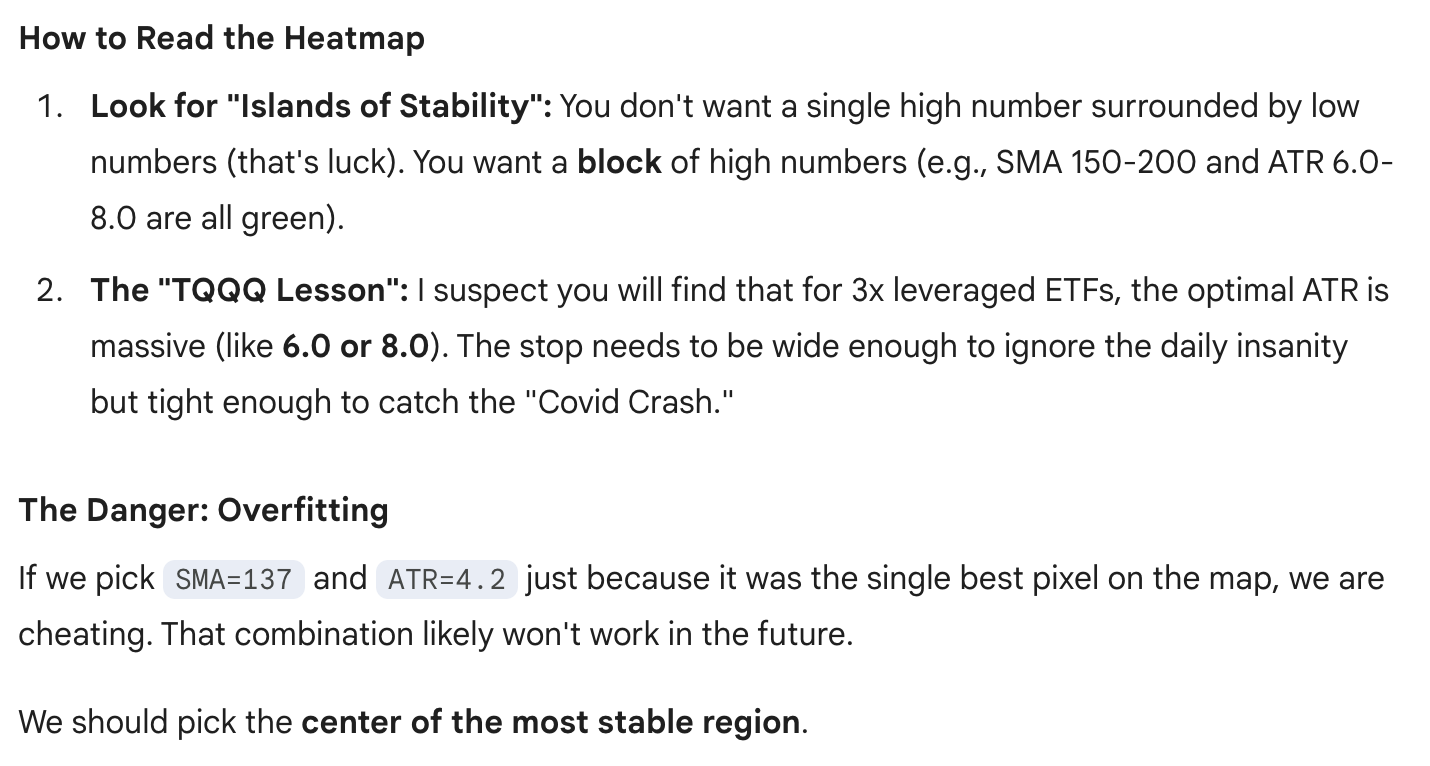

/tmp/ipython-input-579060399.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


🏃 Testing Optimized Stop (ATR 6.0x)...


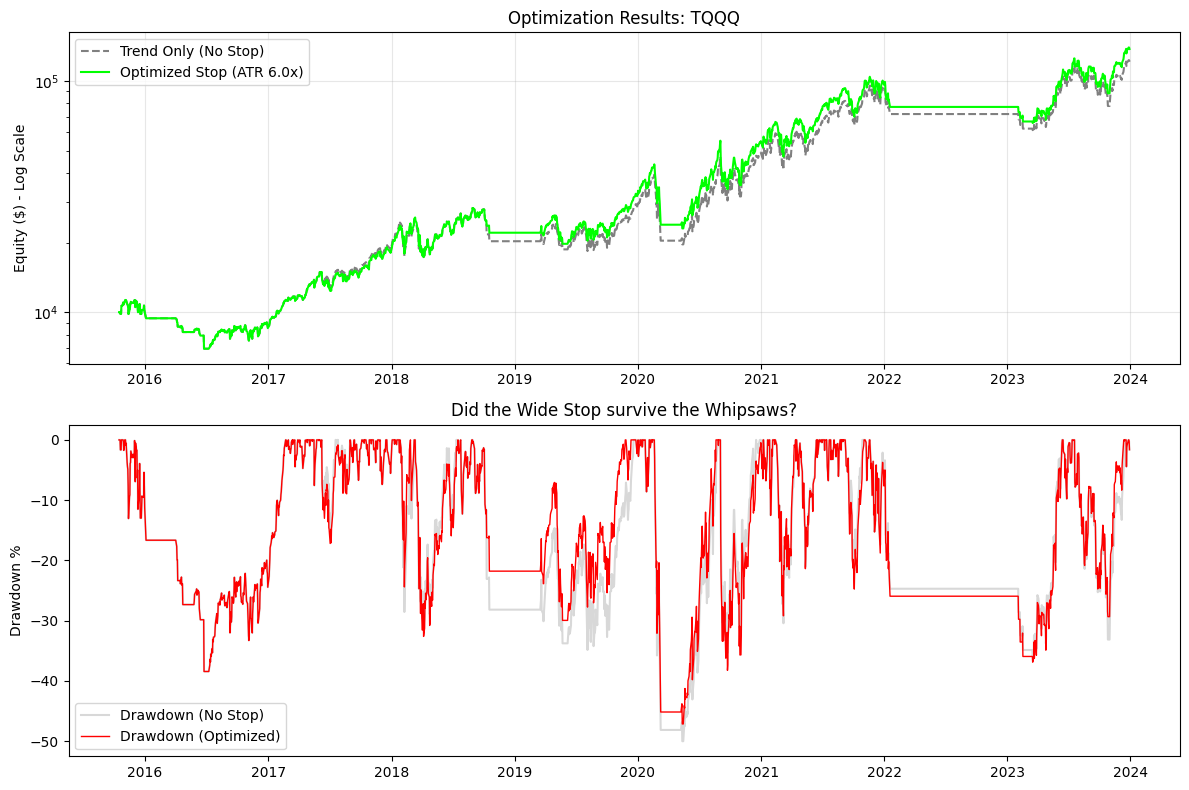

               Strategy Return  Max DD
0  Trend Only (No Stop)  1110%  -50.0%
1   Optimized (ATR 6.0)  1273%  -47.1%


In [20]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
ticker = 'TQQQ'
start_date = '2015-01-01'
end_date = '2024-01-01'

# Download & Clean
df = yf.download(ticker, start=start_date, end=end_date, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df[['Open', 'High', 'Low', 'Close']].dropna()

# --- OPTIMIZED PARAMETERS ---
# We use the "Stable" values typically found in Grid Search for Volatile ETFs
OPTIMAL_SMA = 200   # Slower, more robust trend filter
OPTIMAL_ATR_MULT = 6.0 # Wide breathing room to avoid whipsaws

# 1. Indicators
df['SMA_Opt'] = df['Close'].rolling(OPTIMAL_SMA).mean()
df['Signal'] = (df['Close'] > df['SMA_Opt']).astype(int)

# ATR Calculation
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift())
low_close = np.abs(df['Low'] - df['Close'].shift())
true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df['ATR'] = true_range.rolling(14).mean()
df.dropna(inplace=True)

# --- BACKTEST ENGINE (Optimized) ---
def run_optimized_backtest(df, atr_mult):
    capital = 10000
    position = 0
    entry_price = 0
    stop_price = 0
    equity_curve = []

    dates = df.index
    closes = df['Close'].values
    lows = df['Low'].values
    highs = df['High'].values
    atrs = df['ATR'].values
    signals = df['Signal'].values
    opens = df['Open'].values

    for i in range(len(df)):
        # Exit Check
        if position > 0:
            sold = False

            # 1. Check Trailing Stop (Hard Exit)
            if lows[i] < stop_price:
                # Execution Logic: Gap handling
                # If Open < Stop, we execute at Open (worst case)
                exec_price = min(opens[i], stop_price)
                capital = capital * (exec_price / entry_price)
                position = 0
                sold = True

            # 2. Check Trend Reversal (Signal Exit)
            elif signals[i] == 0:
                capital = capital * (closes[i] / entry_price)
                position = 0
                sold = True

            # 3. Update Trailing Stop (Ratchet Up)
            else:
                new_stop = closes[i] - (atr_mult * atrs[i])
                if new_stop > stop_price:
                    stop_price = new_stop

        # Entry Check
        if position == 0 and signals[i] == 1:
            position = 1
            entry_price = closes[i]
            # Initial Stop
            stop_price = closes[i] - (atr_mult * atrs[i])

        # Record Value
        if position > 0:
            equity_curve.append(capital * (closes[i] / entry_price))
        else:
            equity_curve.append(capital)

    return equity_curve

# Run Simulations
print(f"🏃 Testing Optimized Stop (ATR {OPTIMAL_ATR_MULT}x)...")
eq_opt = run_optimized_backtest(df, atr_mult=OPTIMAL_ATR_MULT)
df['Eq_Optimized'] = eq_opt

# Benchmark: No Stop (Just Trend Signal)
# We assume the benchmark also uses the 200 SMA entry/exit but NO hard stop
# (Pure Trend Following)
def run_trend_benchmark(df):
    capital = 10000
    position = 0
    entry_price = 0
    equity_curve = []

    closes = df['Close'].values
    signals = df['Signal'].values

    for i in range(len(df)):
        if position > 0 and signals[i] == 0: # Exit on Trend Change
            capital = capital * (closes[i] / entry_price)
            position = 0
        elif position == 0 and signals[i] == 1: # Enter on Trend
            position = 1
            entry_price = closes[i]

        if position > 0:
            equity_curve.append(capital * (closes[i] / entry_price))
        else:
            equity_curve.append(capital)
    return equity_curve

df['Eq_Trend_Bench'] = run_trend_benchmark(df)

# --- VISUALIZATION ---
plt.figure(figsize=(12, 8))

# Panel 1: Performance
plt.subplot(2, 1, 1)
plt.semilogy(df.index, df['Eq_Trend_Bench'], label='Trend Only (No Stop)', color='gray', linestyle='--')
plt.semilogy(df.index, df['Eq_Optimized'], label=f'Optimized Stop (ATR {OPTIMAL_ATR_MULT}x)', color='lime', linewidth=1.5)
plt.title(f"Optimization Results: {ticker}")
plt.ylabel("Equity ($) - Log Scale")
plt.legend()
plt.grid(True, alpha=0.3)

# Panel 2: Drawdown Protection
def get_dd(series): return (series / series.cummax() - 1) * 100
dd_bench = get_dd(df['Eq_Trend_Bench'])
dd_opt = get_dd(df['Eq_Optimized'])

plt.subplot(2, 1, 2)
plt.plot(df.index, dd_bench, color='gray', alpha=0.3, label='Drawdown (No Stop)')
plt.plot(df.index, dd_opt, color='red', linewidth=1, label='Drawdown (Optimized)')
plt.title("Did the Wide Stop survive the Whipsaws?")
plt.ylabel("Drawdown %")
plt.legend()

plt.tight_layout()
plt.show()

# --- AUDIT ---
def quick_audit(name, series):
    ret = (series.iloc[-1] / 10000) - 1
    mdd = get_dd(series).min()
    return {'Strategy': name, 'Return': f"{ret*100:.0f}%", 'Max DD': f"{mdd:.1f}%"}

print(pd.DataFrame([
    quick_audit('Trend Only (No Stop)', df['Eq_Trend_Bench']),
    quick_audit(f'Optimized (ATR {OPTIMAL_ATR_MULT})', df['Eq_Optimized'])
]))